In [141]:
import math
import numpy as np
from scipy.stats import norm
from scipy.stats import pearsonr
from collections import defaultdict
from networkx import fast_gnp_random_graph

import netbiol3 as nb
from netective import struct


a = nb.Abasy()

In [142]:
def compute_correlation(props1, props2):
    r, pval = pearsonr(np.fromiter(props1.values(), dtype=float), np.fromiter(props2.values(), dtype=float))
    print(f'pval: {pval}')
    return r

def cv(vals):
    """Coefficient of variation"""
    return np.std(vals)/np.mean(vals)

def corr_diff_test(r1, r2, n1, n2):
    """Test the difference between two correlation coefficients."""
    z1 = 0.5 * math.log((1 + r1) / (1 - r1))
    z2 = 0.5 * math.log((1 + r2) / (1 - r2))
    se = math.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z = (z1 - z2) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return p

In [128]:
regnetid = '511145_v2022_sRDB22_eStrong'
erdos_renyi = 10
norm = True


# biological network to use as a reference
coli = a.regnet(regnetid)
_, coli_struct = struct.struc_props(coli, 'coli', norm=True)

pearson_i = []
props_er = defaultdict(list)
n = coli.number_of_nodes()
m = coli.number_of_edges()

for i in range(erdos_renyi):

    # generate random graph & compute its properties
    ER = nb.RegNet(fast_gnp_random_graph(n, m/(n**2), directed=True))
    _, props_i = struct.struc_props(ER, f'ER_{i}', norm)

    # save ER properties
    for k, v in props_i.items():
        props_er[k].append(v)
    
    # compute correlation between ER and biological network
    r = compute_correlation(coli_struct, props_i)
    pearson_i.append(r)

props_er_avg = {prop: sum(vals)/len(vals) for prop, vals in props_er.items()}
er_av_biol = compute_correlation(coli_struct, props_er_avg)


C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')
C:\Users\jmere\Dropbox (FreyreLab)\Libraries\netbiol3.py:1942: RuntimeWarning: invalid value encountered in double_scalars
C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


0.2178299823255466


C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


0.15945971326194777


C:\Users\jmere\Dropbox (FreyreLab)\Libraries\netbiol3.py:1942: RuntimeWarning: invalid value encountered in double_scalars
C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


...

C:\Users\jmere\Dropbox (FreyreLab)\Libraries\netbiol3.py:1942: RuntimeWarning: invalid value encountered in double_scalars
C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


0.08018526149211451


C:\Users\jmere\Dropbox (FreyreLab)\Libraries\netbiol3.py:1942: RuntimeWarning: invalid value encountered in double_scalars
C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


0.11485541590292768
0.09745536784511048
0.11195189436595332


C:\Users\jmere\Documents\GitHub\FreyreLab\netective\src\netective\struct.py:123: UserWarning: Normalization for clustering coefficient not implemented yet
  warn('Normalization for clustering coefficient not implemented yet')


In [133]:
compute_correlation(coli_struct, props_er_avg)

pval: 0.11195189436595332


0.462020825861351

    Por que valores menores a 0 en CK.rsquared_adj?

In [88]:

kc = ER.k_clustering()
CK = nb.Ck(kc.values())
CK.rsquared_adj, CK.rsquared

C:\Users\jmere\Dropbox (FreyreLab)\Libraries\netbiol3.py:1942: RuntimeWarning: invalid value encountered in double_scalars


(-0.07713894683287581, 0.07673804557182073)

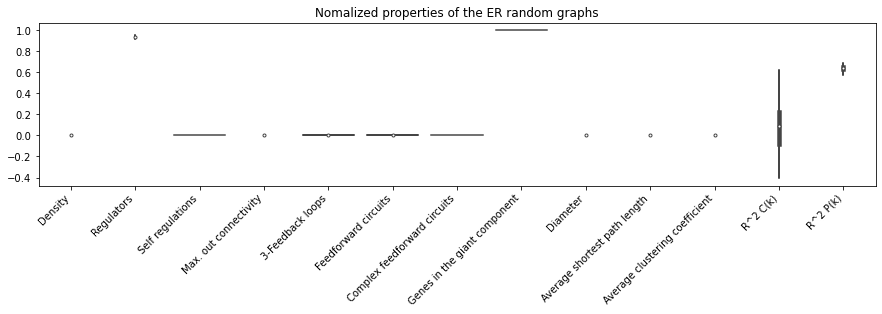

In [89]:
# plot a violinplot for each list of values in props_er, use the keys as labels

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 3))
sns.violinplot(data=list(props_er.values()), ax=ax)
ax.set_xticklabels(props_er.keys(), rotation=45, ha='right')
ax.set_title('Nomalized properties of the ER random graphs')
plt.show()

        explanation negative Rsqrt https://www.ibm.com/docs/fi/cognos-analytics/11.1.0?topic=terms-adjusted-r-squared and https://towardsdatascience.com/explaining-negative-r-squared-17894ca26321

c:\Users\jmere\.conda\envs\py3FL\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in double_scalars
  This is separate from the ipykernel package so we can avoid doing imports until


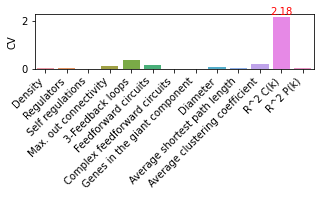

CV for Self regulations: nan
CV for Complex feedforward circuits: nan


In [94]:
# compute the coefficient of variation for each property in props_er and save it in a dict
props_er_cv = {prop: cv(vals) for prop, vals in props_er.items()}

# plot a barplot for each list of values in props_er, use the keys as labels
fig, ax = plt.subplots(figsize=(5, 1))
sns.barplot(x=list(props_er_cv.keys()), y=list(props_er_cv.values()), ax=ax)
ax.set_xticklabels(props_er_cv.keys(), rotation=45, ha='right')
ax.set_ylabel('CV')

# plot the vale of the coefficient of variation for each property if value > 1. Do it on top of the corresponding barplot
for i, (prop, cv_) in enumerate(props_er_cv.items()):
    if cv_ > 1:
        ax.text(i, cv_, f'{cv_:.2f}', ha='center', va='bottom', color='red')
# display 0, the max value from props_er_cv.values() and steps of 1 between them in the yticklabels
ax.set_yticks(np.arange(0, max(props_er_cv.values())+1, 2))


plt.show()




# print properties for which the coefficient of variation is nan
for prop, cv_ in props_er_cv.items():
    if np.isnan(cv_):
        print(f'CV for {prop}: {cv_}')

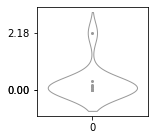

In [93]:
# CVs distribution
fig, ax = plt.subplots(figsize=(2, 2))
sns.violinplot(data=list(props_er_cv.values()), ax=ax, inner='point', color='white', linewidth=1)
ax.set_yticks([0, min(props_er_cv.values()), max(props_er_cv.values())])

0.48144991080059363

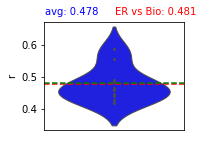

In [124]:
# plot violinplot of pearson_i
fig, ax = plt.subplots(figsize=(2.5, 2))
sns.violinplot(data=pearson_i, ax=ax, color='blue', inner='point', linewidth=1)
ax.set_ylabel('r')
ax.set_xticklabels([])
ax.set_xticks([])

r_avg = np.mean(pearson_i)
ax.axhline(r_avg, color='red', linestyle='--')
ax.axhline(er_av_biol, color='green', linestyle='--')

# add text to identify each line
max_r = max(pearson_i)+.1
ax.text(-0.3, max_r, f'avg: {r_avg:.3f}', ha='center', va='bottom', color='blue')
ax.text(0.3, max_r, f'ER vs Bio: {er_av_biol:.3f}', ha='center', va='bottom', color='red')


plt.show()


In [140]:


corr_diff_test(r_avg, er_av_biol, len(coli_struct), len(coli_struct))

0.9642639013315908